In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


## 1.Import dataset

In [2]:
data = '/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv'
churn = pd.read_csv(data)

## 2. EDA

In [3]:
churn.shape

(7043, 21)

In [4]:
churn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
churn.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [6]:
churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
churn.drop(['customerID'], axis=1, inplace=True) # we don't need this column

In [8]:
churn.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [9]:
print(churn.isnull().sum())

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [10]:
categorical = [var for var in churn.columns if churn[var].dtype=='O']
print(f"Number of categorical variables: {len(categorical)}")
print("Categorical variables:", categorical)

Number of categorical variables: 17
Categorical variables: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


In [11]:
churn[categorical].head()

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
0,Female,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,No
1,Male,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,1889.5,No
2,Male,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,108.15,Yes
3,Male,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),1840.75,No
4,Female,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,151.65,Yes


## 3. Prepare the Data

In [12]:
churn['TotalCharges'] = pd.to_numeric(churn['TotalCharges'], errors='coerce')

In [13]:
churn['Churn'] = churn['Churn'].map({'Yes': 1, 'No': 0})

In [14]:
nan_count = churn['TotalCharges'].isnull().sum()
print(f"\n number of NaN in TotalCharges : {nan_count}")


 number of NaN in TotalCharges : 11


In [15]:
churn['TotalCharges'] = churn['TotalCharges'].fillna(
    churn['tenure'] * churn['MonthlyCharges']
)

In [16]:
churn.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [17]:
# 1. gender → Male=1, Female=0
churn['gender'] = churn['gender'].map({'Male': 1, 'Female': 0})

# 2. Partner → Yes=1, No=0
churn['Partner'] = churn['Partner'].map({'Yes': 1, 'No': 0})

# 3. Dependents → Yes=1, No=0
churn['Dependents'] = churn['Dependents'].map({'Yes': 1, 'No': 0})

# 4. PhoneService → Yes=1, No=0
churn['PhoneService'] = churn['PhoneService'].map({'Yes': 1, 'No': 0})

# 5. PaperlessBilling → Yes=1, No=0
churn['PaperlessBilling'] = churn['PaperlessBilling'].map({'Yes': 1, 'No': 0})

In [18]:
# One-hot encoding for categorical variables with 3+ categories

# Columns to apply one-hot encoding
one_hot_cols = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaymentMethod'
]

# Apply one-hot encoding
churn_encoded = pd.get_dummies(churn, columns=one_hot_cols, drop_first=True)

# Print results
print("One-hot encoding results:")
print(f"Before: {churn.shape[1]} columns")
print(f"After:  {churn_encoded.shape[1]} columns")
print(f"Added:  {churn_encoded.shape[1] - churn.shape[1]} new columns")


# Update dataframe
churn = churn_encoded

print(f"   Total columns: {churn.shape[1]}")


One-hot encoding results:
Before: 20 columns
After:  31 columns
Added:  11 new columns
   Total columns: 31


In [19]:
churn.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False


In [20]:
churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   PaperlessBilling                       7043 non-null   int64  
 7   MonthlyCharges                         7043 non-null   float64
 8   TotalCharges                           7043 non-null   float64
 9   Churn                                  7043 non-null   int64  
 10  MultipleLines_No phone service         7043 non-null   bool   
 11  Mult

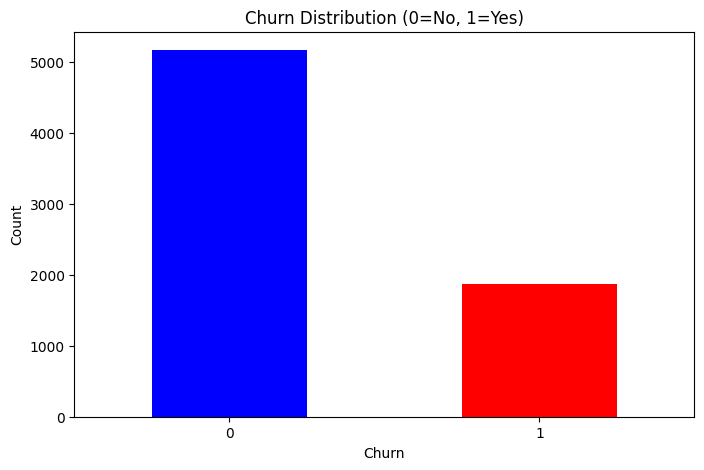

Churn rate: 26.5%


In [21]:
from matplotlib import pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
churn['Churn'].value_counts().plot(kind='bar', color=['blue', 'red'])
plt.title('Churn Distribution (0=No, 1=Yes)')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

print(f"Churn rate: {(churn['Churn'].mean()*100):.1f}%")

<Axes: xlabel='Churn', ylabel='TotalCharges'>

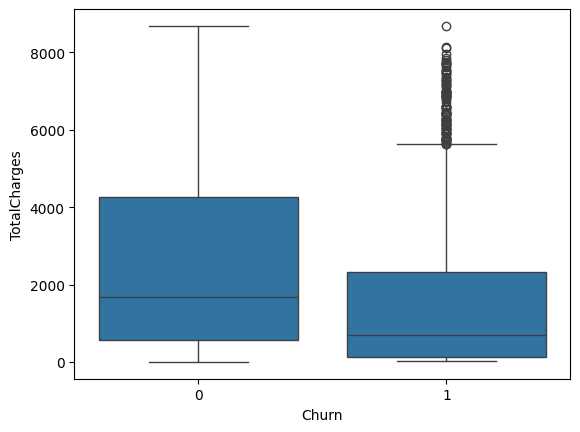

In [22]:
sns.boxplot(data = churn, x = 'Churn', y = 'TotalCharges')

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

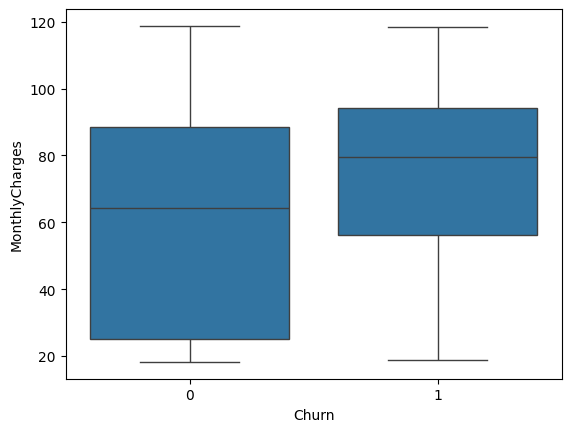

In [23]:
sns.boxplot(data = churn, x = 'Churn', y = 'MonthlyCharges')

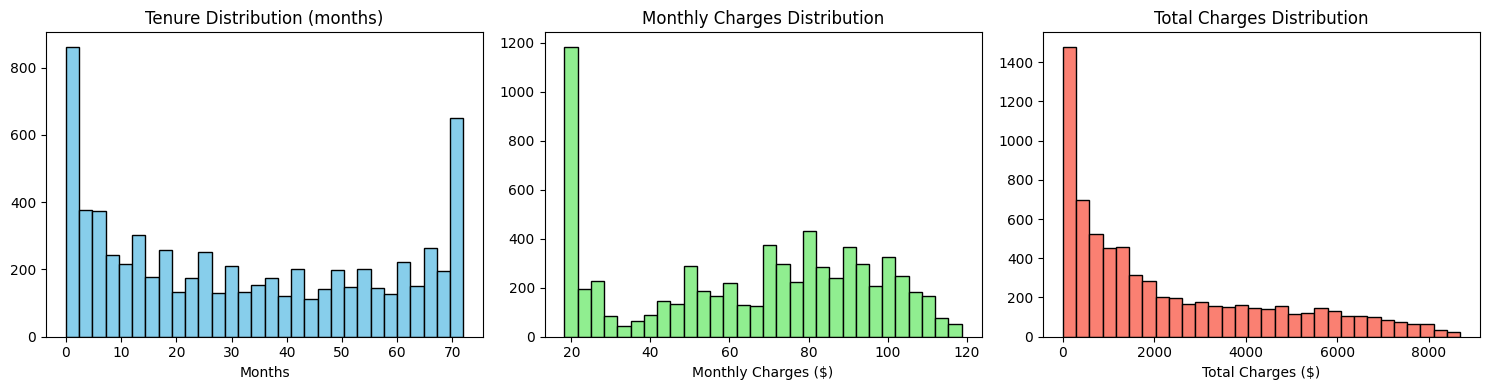

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# tenure
axes[0].hist(churn['tenure'], bins=30, color='skyblue', edgecolor='black')
axes[0].set_title('Tenure Distribution (months)')
axes[0].set_xlabel('Months')

# MonthlyCharges
axes[1].hist(churn['MonthlyCharges'], bins=30, color='lightgreen', edgecolor='black')
axes[1].set_title('Monthly Charges Distribution')
axes[1].set_xlabel('Monthly Charges ($)')

# TotalCharges
axes[2].hist(churn['TotalCharges'], bins=30, color='salmon', edgecolor='black')
axes[2].set_title('Total Charges Distribution')
axes[2].set_xlabel('Total Charges ($)')

plt.tight_layout()
plt.show()

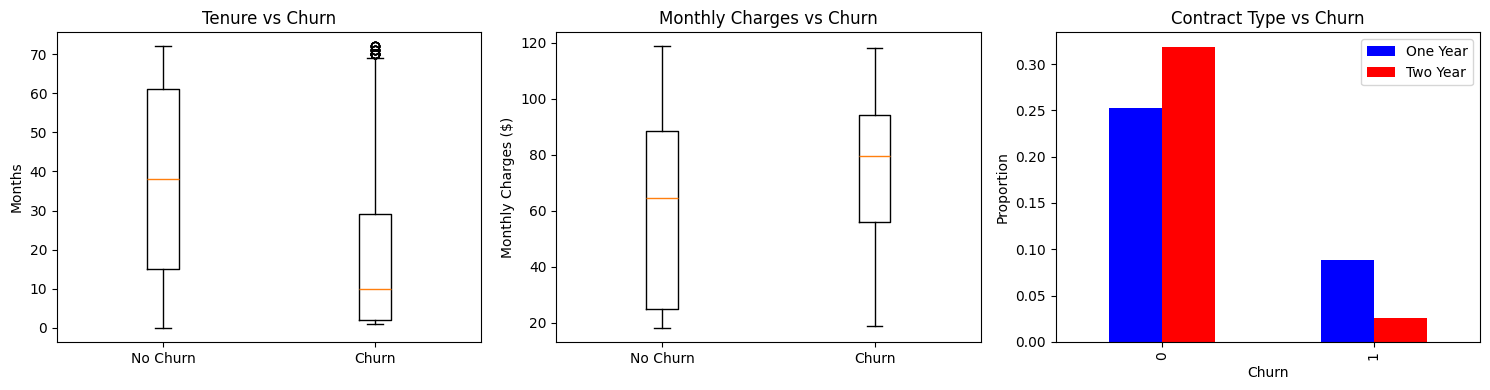

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# tenure vs churn
axes[0].boxplot([churn[churn['Churn']==0]['tenure'], 
                 churn[churn['Churn']==1]['tenure']])
axes[0].set_title('Tenure vs Churn')
axes[0].set_xticklabels(['No Churn', 'Churn'])
axes[0].set_ylabel('Months')

# MonthlyCharges vs churn
axes[1].boxplot([churn[churn['Churn']==0]['MonthlyCharges'], 
                 churn[churn['Churn']==1]['MonthlyCharges']])
axes[1].set_title('Monthly Charges vs Churn')
axes[1].set_xticklabels(['No Churn', 'Churn'])
axes[1].set_ylabel('Monthly Charges ($)')

# Contract type vs churn (one-hot'tan)
if 'Contract_One year' in churn.columns:
    contract_churn = churn.groupby('Churn')[['Contract_One year', 'Contract_Two year']].mean()
    contract_churn.plot(kind='bar', ax=axes[2], color=['blue', 'red'])
    axes[2].set_title('Contract Type vs Churn')
    axes[2].set_xlabel('Churn')
    axes[2].set_ylabel('Proportion')
    axes[2].legend(['One Year', 'Two Year'])

plt.tight_layout()
plt.show()

<Axes: xlabel='tenure', ylabel='Churn'>

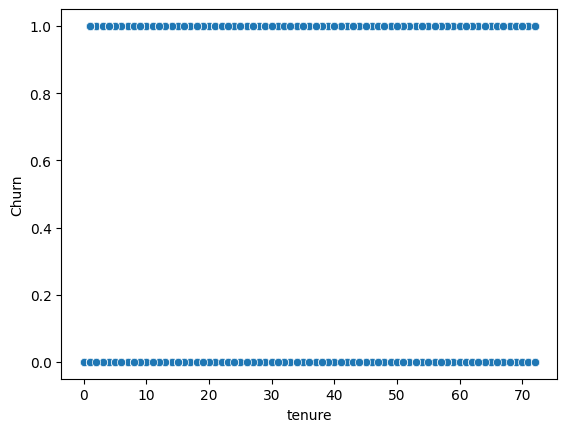

In [26]:
sns.scatterplot(x = churn['tenure'], y = churn['Churn'])

<Axes: xlabel='MonthlyCharges', ylabel='Churn'>

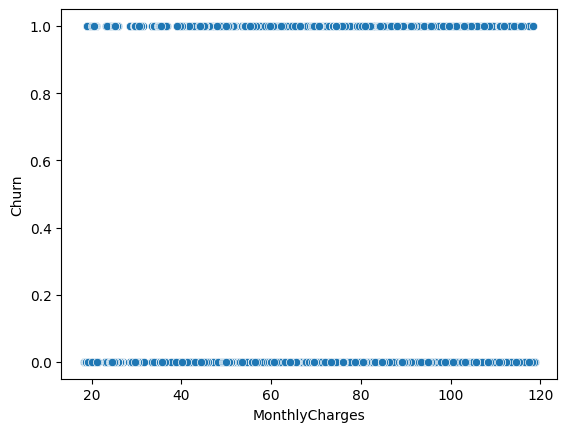

In [27]:
sns.scatterplot(x = churn['MonthlyCharges'], y = churn['Churn'])

In [28]:
y = churn['Churn']
X = churn.drop(['Churn'], axis=1) 

print("Dataset shapes:")
print(f"X (features): {X.shape}")
print(f"y (target):   {y.shape}")

Dataset shapes:
X (features): (7043, 30)
y (target):   (7043,)


In [29]:
#  Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    train_size=0.8, 
    stratify=y, 
    random_state=42
)

In [30]:
# Scaling 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 4. Train and Evaluate the Model

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.model_selection import cross_val_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Cross-validation
print("\n CROSS-VALIDATION (5-fold):")
classifier = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)

cv_scores = cross_val_score(
    classifier,
    X_train_scaled, 
    y_train,
    cv=5,
    scoring='accuracy'
)

print(f"Mean CV accuracy: {cv_scores.mean():.4f}")
print(f"Std: {cv_scores.std():.4f}")


 CROSS-VALIDATION (5-fold):
Mean CV accuracy: 0.7515
Std: 0.0216


In [32]:
# 2. Train final model

model = LogisticRegression(
    max_iter=1000, 
    class_weight='balanced',  # Dengesiz veri için
    random_state=42
)
model.fit(X_train_scaled, y_train)


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [33]:
# 3. Predict on test set
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]  # Churn=1 olasılıkları

In [34]:
#4. Calculate metrics
test_accuracy = model.score(X_test_scaled, y_test)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"\n MODEL PERFORMANCE:")
print(f"   Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"   ROC-AUC:  {roc_auc:.4f}")


 MODEL PERFORMANCE:
   Accuracy: 0.7402 (74.02%)
   ROC-AUC:  0.8414


In [35]:
#  5. Detailed classification report
print("\n CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred))


 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



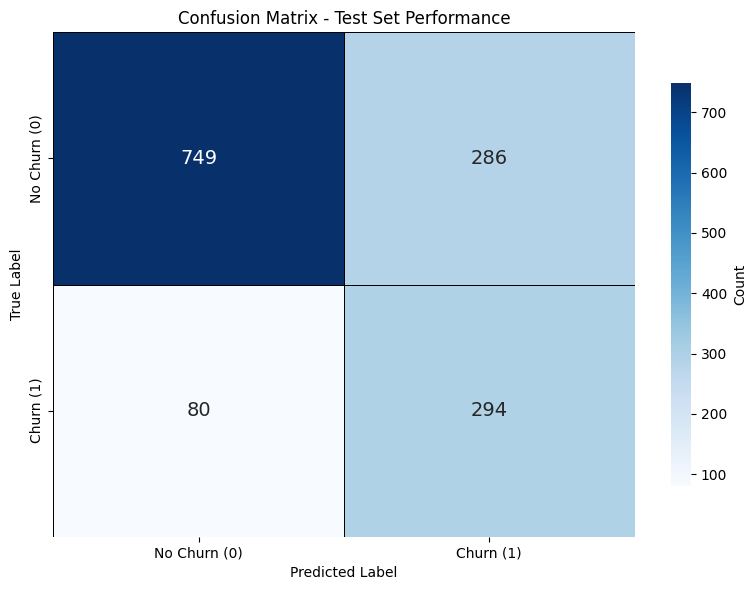

In [36]:
# 6. Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            linewidths=0.7,
            linecolor='black',
            xticklabels=['No Churn (0)', 'Churn (1)'],
            yticklabels=['No Churn (0)', 'Churn (1)'],
            cbar_kws={'label': 'Count', 'shrink': 0.8},
            annot_kws={'size': 14})
plt.title('Confusion Matrix - Test Set Performance')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

In [37]:
# 7. Feature importance (coefficients)

coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_[0],
    'abs_coef': abs(model.coef_[0])
}).sort_values('abs_coef', ascending=False)

print(coef_df.head(10).to_string(index=False))

                       feature  coefficient  abs_coef
                        tenure    -1.159048  1.159048
                MonthlyCharges    -1.039440  1.039440
   InternetService_Fiber optic     0.808897  0.808897
             Contract_Two year    -0.617746  0.617746
                  TotalCharges     0.494748  0.494748
             Contract_One year    -0.296706  0.296706
           StreamingMovies_Yes     0.285948  0.285948
               StreamingTV_Yes     0.273209  0.273209
             MultipleLines_Yes     0.201165  0.201165
PaymentMethod_Electronic check     0.188783  0.188783


## 5. Interpret the Model

In [38]:
# 1. Intercept (beta_0)
print(f"\n INTERCEPT (beta_0): {model.intercept_[0]:.4f}")
print("   (Baseline log-odds when all features = 0)")


 INTERCEPT (beta_0): -0.6744
   (Baseline log-odds when all features = 0)


In [39]:
# 2. Coefficients (log-odds)
print("\n COEFFICIENTS (log-odds):")
log_odds = np.round(model.coef_[0], 4)

coef_df = pd.DataFrame({
    'feature': X.columns,
    'log_odds': log_odds,
    'abs_log_odds': np.abs(log_odds)
}).sort_values('abs_log_odds', ascending=False)

print(coef_df.head(10).to_string(index=False))


 COEFFICIENTS (log-odds):
                       feature  log_odds  abs_log_odds
                        tenure   -1.1590        1.1590
                MonthlyCharges   -1.0394        1.0394
   InternetService_Fiber optic    0.8089        0.8089
             Contract_Two year   -0.6177        0.6177
                  TotalCharges    0.4947        0.4947
             Contract_One year   -0.2967        0.2967
           StreamingMovies_Yes    0.2859        0.2859
               StreamingTV_Yes    0.2732        0.2732
             MultipleLines_Yes    0.2012        0.2012
PaymentMethod_Electronic check    0.1888        0.1888


In [40]:
# 3. Odds Ratios
print("\nODDS RATIOS (exp(coef)):")
odds_ratios = np.round(np.exp(log_odds), 4)

odds_df = pd.DataFrame({
    'feature': X.columns,
    'odds_ratio': odds_ratios,
    'abs_odds': np.abs(odds_ratios - 1)  # 1'den ne kadar uzak?
}).sort_values('abs_odds', ascending=False)

print(odds_df.head(10).to_string(index=False))



ODDS RATIOS (exp(coef)):
                       feature  odds_ratio  abs_odds
   InternetService_Fiber optic      2.2454    1.2454
                        tenure      0.3138    0.6862
                MonthlyCharges      0.3537    0.6463
                  TotalCharges      1.6400    0.6400
             Contract_Two year      0.5392    0.4608
           StreamingMovies_Yes      1.3310    0.3310
               StreamingTV_Yes      1.3142    0.3142
             Contract_One year      0.7433    0.2567
             MultipleLines_Yes      1.2229    0.2229
PaymentMethod_Electronic check      1.2078    0.2078


In [41]:
# 4. Interpretation examples
print("\nINTERPRETATION EXAMPLES (Top 5):")


top_features = odds_df.head(5)
for _, row in top_features.iterrows():
    feature = row['feature']
    odds = row['odds_ratio']
    
    if odds > 1:
        print(f"• {feature}:")
        print(f"  Odds Ratio = {odds:.2f}")
        print(f"  → When this feature increases by 1 unit, CHURN odds increase by {odds:.1f} TIMES")
    else:
        print(f"• {feature}:")
        print(f"  Odds Ratio = {odds:.2f}")
        print(f"  → When this feature increases by 1 unit, CHURN odds decrease by {1/odds:.1f} TIMES")
    print()


INTERPRETATION EXAMPLES (Top 5):
• InternetService_Fiber optic:
  Odds Ratio = 2.25
  → When this feature increases by 1 unit, CHURN odds increase by 2.2 TIMES

• tenure:
  Odds Ratio = 0.31
  → When this feature increases by 1 unit, CHURN odds decrease by 3.2 TIMES

• MonthlyCharges:
  Odds Ratio = 0.35
  → When this feature increases by 1 unit, CHURN odds decrease by 2.8 TIMES

• TotalCharges:
  Odds Ratio = 1.64
  → When this feature increases by 1 unit, CHURN odds increase by 1.6 TIMES

• Contract_Two year:
  Odds Ratio = 0.54
  → When this feature increases by 1 unit, CHURN odds decrease by 1.9 TIMES



In [42]:
# Example: Find Contract_Two year
if 'Contract_Two year' in X.columns:
    idx = list(X.columns).index('Contract_Two year')
    coef = model.coef_[0][idx]
    odds = np.exp(coef)
    
    print(f"Contract_Two year coefficient: {coef:.4f}")
    print(f"Odds Ratio: {odds:.4f}")
    
    if odds < 1:
        reduction = (1 - odds) * 100
        print(f"2-year contract reduces churn risk by {reduction:.1f}%!")
    else:
        increase = (odds - 1) * 100
        print(f"2-year contract increases churn risk by {increase:.1f}%!")

Contract_Two year coefficient: -0.6177
Odds Ratio: 0.5392
2-year contract reduces churn risk by 46.1%!
